In [25]:
from glob import glob
file_path = r'C:\skn29_lecture\머신러닝\실습\data\*.csv'
files = glob(file_path)
files = files[4:]
files

['C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_강원_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_경기_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_경남_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_경북_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_광주_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_대구_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_대전_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_부산_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_서울_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_세종_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_울산_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_인천_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(상권)정보_전남_202512.csv',
 'C:\\skn29_lecture\\머신러닝\\실습\\data\\소상공인시장진흥공단_상가(

In [43]:
import pandas as pd
df = pd.read_csv(files[0])
# 불필요한 컬럼제거 - 의미가 중복된 데이터는 제거하는 것이 좋다.


In [44]:
new_cols = ['상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', 
            '시도명', '시군구명', '행정동명', '법정동명', '도로명주소', '위도', '경도']
df[new_cols].head()

,상호명,지점명,상권업종대분류명,상권업종중분류명,상권업종소분류명,시도명,시군구명,행정동명,법정동명,도로명주소,위도,경도
0,디자인바다,NaN,과학·기술,인쇄·제품제작,명함/간판/광고물 제작,강원특별자치도,강릉시,포남1동,포남동,강원특별자치도 강릉시 성덕포남로200번길 3,37.769424,128.907359
1,수리봉약선요리,전문점,음식,한식,백반/한정식,강원특별자치도,원주시,흥업면,흥업면,강원특별자치도 원주시 흥업면 자재기길 65-2,37.297825,127.923945
2,북스타문고,NaN,소매,오락용품 소매,서점,강원특별자치도,원주시,단계동,단계동,강원특별자치도 원주시 서원대로 121-1,37.346880,127.926882
3,봄내치킨앤떡볶이,NaN,음식,기타 간이,김밥/만두/분식,강원특별자치도,춘천시,석사동,석사동,강원특별자치도 춘천시 퇴계로 220-19,37.855030,127.742691
4,다빈치모텔,NaN,숙박,일반 숙박,여관/모텔,강원특별자치도,강릉시,강동면,강동면,강원특별자치도 강릉시 강동면 헌화로 920-40,37.682861,129.041861


In [45]:
# 결측치 확인
shop = df[new_cols]
shop.isnull().sum()

상호명              0
지점명         100730
상권업종대분류명         0
상권업종중분류명         0
상권업종소분류명         0
시도명              0
시군구명             0
행정동명             0
법정동명             0
도로명주소            0
위도               0
경도               0
dtype: int64

In [46]:
%pip install missingno

Note: you may need to restart the kernel to use updated packages.


In [47]:
# 한글설정
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')


<Axes: >

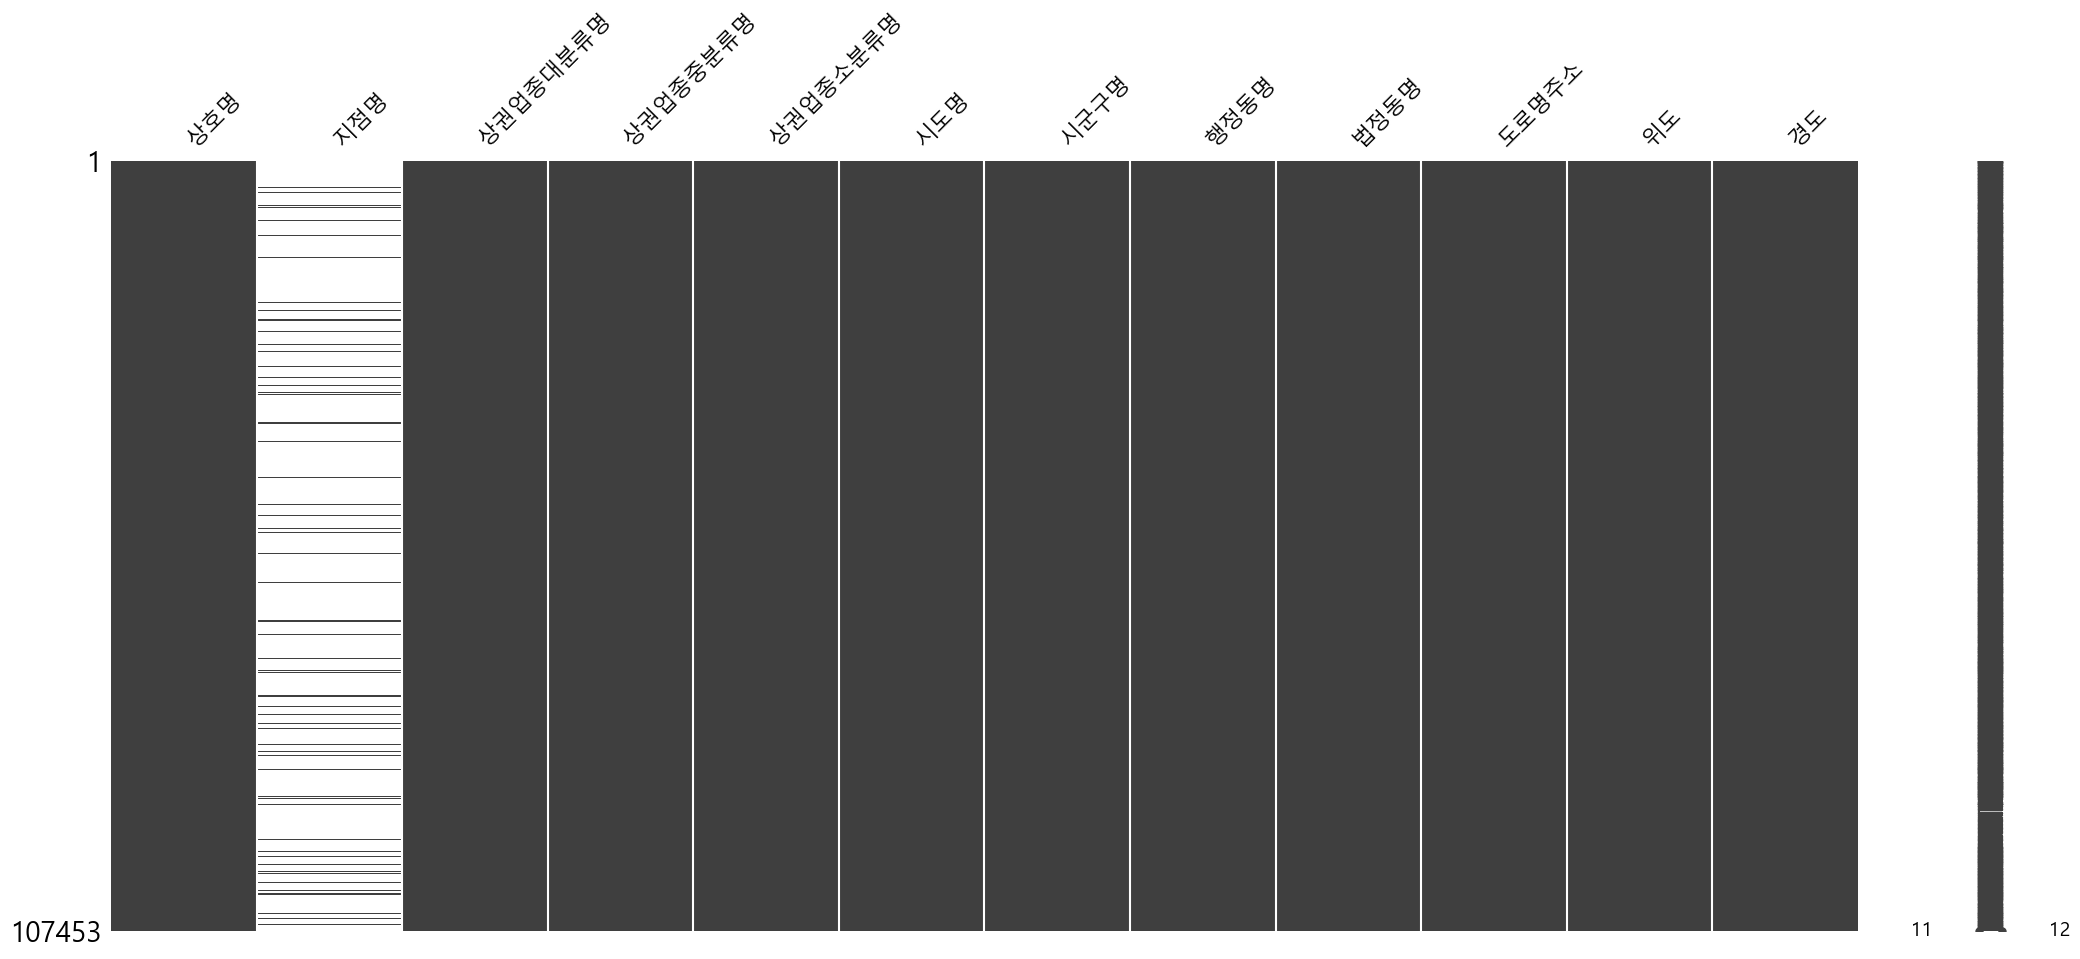

In [48]:
# 결측치 시각적으로 보기
import missingno as msno
msno.matrix(shop)

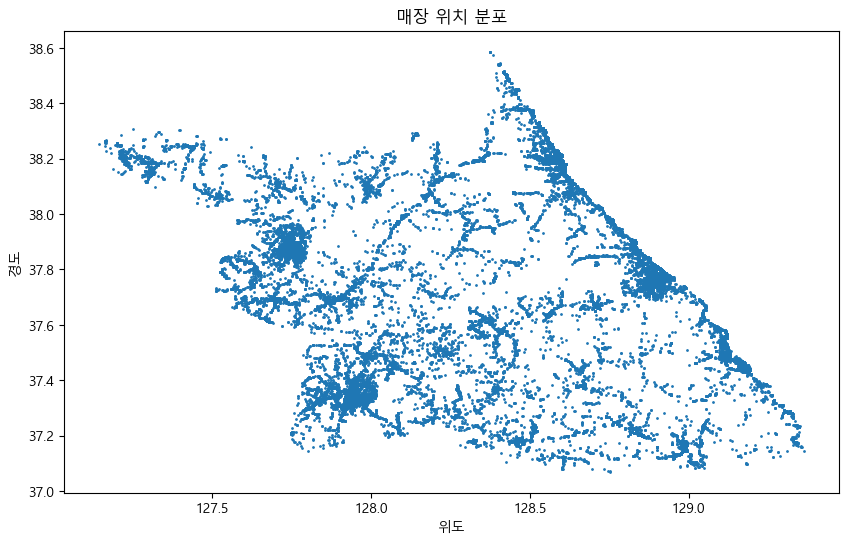

In [49]:
fig,ax = plt.subplots(figsize=(10, 6))
plt.plot(shop['경도'],shop['위도'], 'o', markersize=1)
plt.xlabel('위도')
plt.ylabel('경도')
plt.title('매장 위치 분포')
plt.show()

<Axes: xlabel='경도', ylabel='위도'>

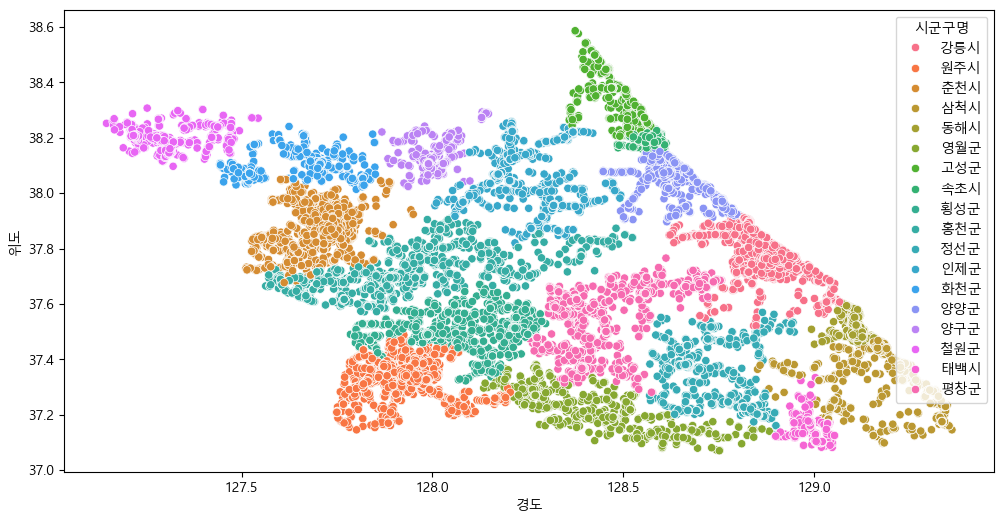

In [50]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=shop,x='경도',y='위도',hue='시군구명',ax=ax)

<Axes: xlabel='경도', ylabel='위도'>

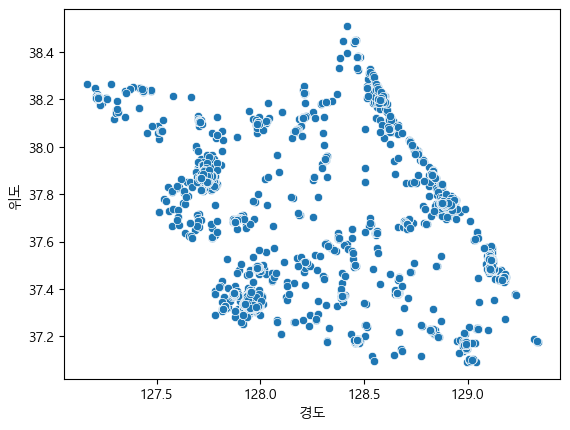

In [55]:
# 상권업종 대분류명이  교육과 관련된 정보
import numpy as np
edu_shop = shop[shop['상권업종대분류명']=='교육']
sns.scatterplot(edu_shop,x='경도',y='위도')



In [ ]:
# 반경 200m 내 점포수
# 동일 업종수
# 경쟁 강도(같은 업종 density)

# step1 결측치 제거
# step2 공간 Feature 생성  KDTree
# step3 모델 정의(분류 회귀)
# step4 학습
from sklearn.neighbors import BallTree
coors = np.radians(shop[['위도','경도']].values)  # 각도를 degree ~~도   -> 라디안 radian으로 변환
tree = BallTree(coors,metric='haversine')  # 단위가 radian

# 500m반경
radius = 0.5 / 6371
counts = tree.query_radius(coors,r=radius,count_only=True)
shop.loc[:,'store_density_500m']  = counts

In [63]:
# 음식점 기준
target_category = '음식'
food_mask = (shop['상권업종대분류명'] == target_category)

food_coors = np.radians(shop.loc[food_mask,['위도','경도']].values)
food_tree = BallTree(food_coors,metric='haversine') 

# 전체 좌표 기준으로 음식점 수 계산
food_counts = food_tree.query_radius(coors, r=radius, count_only=True)
shop.loc[:,'fodd_density_500'] = food_counts

In [69]:
# 경쟁강도
shop.loc[:,'competition_ratio'] = (shop['fodd_density_500'] / shop['store_density_500m'])
# 0에 가까울수록 경쟁적음  1에 가까울수록 경쟁이 심함

In [93]:
indices = tree.query_radius(coors, r=radius)
diversity = [len(shop.iloc[idx_list]['상권업종중분류명'].unique()) for idx_list in indices]

In [94]:
shop['category_deiversity_500m'] = diversity

C:\Users\Playdata\AppData\Local\Temp\ipykernel_30384\333347142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shop['category_deiversity_500m'] = diversity


In [95]:
shop.loc[:,'위도':].head(2)

,위도,경도,store_density_500m,fodd_density_500,competition_ratio,category_deiversity_500m
0,37.769424,128.907359,879,323,0.367463,64
1,37.297825,127.923945,58,22,0.379310,24


In [125]:
X = shop.loc[:,'위도':]
y = (
    0.4*X['store_density_500m']  # 전체상권 활성도
    -0.3*X['competition_ratio']  # 경쟁강도(패널티)
    +0.3*X['category_deiversity_500m']  #상권의 다양성
)

In [126]:
# 주변 점포수 많음 - >사람 많음 -> 좋은 입지
X.head()

,위도,경도,store_density_500m,fodd_density_500,competition_ratio,category_deiversity_500m
0,37.769424,128.907359,879,323,0.367463,64
1,37.297825,127.923945,58,22,0.379310,24
2,37.346880,127.926882,1169,497,0.425150,61
3,37.855030,127.742691,866,215,0.248268,60
4,37.682861,129.041861,67,24,0.358209,10


In [129]:
from lightgbm import LGBMRegressor
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(X,y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [130]:
# 기존 매장위치가 아니라 새로운 후보 위치를 만들어서 평가
# 새로 어디에 창업할지에 대한 정보가 없음
# 가상의 후보 위치 생성
########## 데이터가 존재하는 곳의 지역범위 추출
lat_min, lat_max =  shop['위도'].min(), shop['위도'].max()
lon_min, lon_max = shop['경도'].min(), shop['경도'].max()
################### 격자 생성
lat_grid = np.linspace(lat_min,lat_max, 50) #50
lon_grid = np.linspace(lon_min,lon_max, 50) #50 
# 2500 후보 위치
# 2D grid 생성  위도 경도 모든 조합 생성
grid = np.array(np.meshgrid(lat_grid,lon_grid)).T.reshape(-1,2)
# lat : [a,b]  long: [x,y]
#  [a,x] [a,y] [b,x] [b,y]
# dataframe 변환
grid_df = pd.DataFrame(grid, columns=['위도','경도'])
# 라디안 변환
grid_coords = np.radians(grid)

# 주변상권분석(주변 500m 점포가 몇개?)
grid_store_counts = tree.query_radius(grid_coords,r=radius,count_only=True)
grid_df['store_density_500m'] = grid_store_counts
# 이 위치 주변에 음식점이 몇개 있냐?
grid_food_counts = food_tree.query_radius(grid_coords,r=radius,count_only=True)
grid_df['food_density_500m'] = grid_food_counts

grid_df['competition_ratio'] = (
    grid_df['food_density_500m'] / grid_df['store_density_500m']
)

#다양성
grid_indicies = tree.query_radius(grid_coords,r=radius)

grid_diversity = [   shop.iloc[idx_list]['상권업종중분류명'].unique() 
                  for idx_list in grid_indicies ]

grid_df.loc[:,'category_deiversity_500m'] = [len(array) for array in grid_diversity]

# 예측 및 추천
grid_x = grid_df.copy()
grid_df['pred_score'] = model.predict(grid_x)


In [132]:
# top 10 추천
top_k = grid_df.sort_values('pred_score',ascending=False).head(10)
top_k

,위도,경도,store_density_500m,food_density_500m,competition_ratio,category_deiversity_500m,pred_score
1313,37.874754,127.733631,911,297,0.326015,65,383.387442
418,37.317591,127.959825,886,309,0.348758,59,371.018170
1882,38.215242,128.593168,349,130,0.372493,50,154.513955
287,37.224731,128.819362,321,131,0.408100,46,142.081707
516,37.379498,127.869347,270,69,0.255556,33,118.651615
1832,38.184289,128.593168,229,97,0.423581,37,103.570536
1139,37.750940,128.909840,200,60,0.300000,42,92.199938
1363,37.905708,127.733631,156,66,0.423077,28,70.474185
729,37.503312,128.457452,118,54,0.457627,31,55.697104
398,37.286638,129.316989,118,27,0.228814,16,51.989582


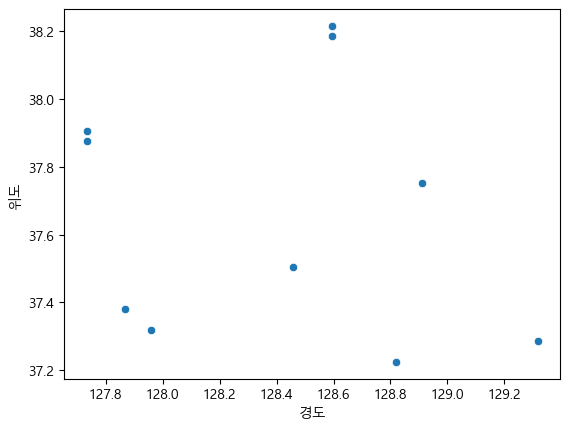

In [133]:
sns.scatterplot(data=top_k, x='경도',y='위도')
plt.show()

In [ ]:
%pip install folium

In [137]:
from IPython.display import display
import folium
# 지도의 중심
center_lat =  shop['위도'].mean()
center_lon =  shop['경도'].mean()
m = folium.Map(location=[center_lat, center_lon],zoom_start=13)
for idx, row in top_k.iterrows():
    folium.Marker(
        location = [ row['위도']  , row['경도']  ],
        popup = f"score:{row['pred_score']:.2f}",
        icon = folium.Icon(color='red'),
    ).add_to(m)
display(m)